# 2D Pulsar Distance Pair Scanner

Scans the **joint likelihood surface** over two pulsar distances simultaneously,
with all other parameters fixed at their injected truth values.

**Setup**
- 5 noise-free pulsars (pure CW signal, no white/red noise, no GWB)
- Single CW injection at `log10_h = -12`
- 2D grid ≈ 80 × 80 over each pair's EM distance prior (mean ± 3σ)

**What to expect with a single CW**
A single CW is degenerate in each pulsar's distance: the pulsar term can be satisfied
at any integer multiple of the mode spacing `dL`. The 2D surface should show a
periodic *grid* of peaks — all at roughly the same height — with the truth at one node.
This mirrors the 1D result from `00_noisefree_distance_landscape.ipynb`.

In [22]:
import sys, importlib
sys.path.insert(0, "../CW_lnL_check")
import cw_helpers
importlib.reload(cw_helpers)
from cw_helpers import *

import time
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

## 1. `scan_pulsar_pair_2d` — 2D distance scanner

Evaluates `logl_fn` on an (n_i × n_j) grid.

**Implementation**
- Flatten the meshgrid to a 1-D list of (Di, Dj) pairs
- Replace the two distance entries in `base_values` for each point
- Use chunked `jax.vmap + jit` identical to `scan_pulsar_distance` in `cw_helpers`
- A local cache avoids re-compiling the vmapped function across calls with the same `logl_fn`
- `indexing='ij'` → `lnL_surface[i, j]` = lnL at `(grid_i[i], grid_j[j])`

In [23]:
# 2D scanner lives in cw_helpers now.
# Keeping this cell intentionally minimal prevents stale notebook code from
# shadowing the tested implementation imported above via `from cw_helpers import *`.
print("Using cw_helpers.scan_pulsar_pair_2d and cw_helpers.scan_pair_window_2d")


## 2. Plotting helper — `plot_2d_scan`

Produces a 2×2 figure:

| Panel | Content |
|-------|---------|
| **(top-left)** | 2D `contourf` of Δln L = lnL − max(lnL). Gold ★ = truth, red ✕ = grid max. Dashed ellipses at 1/2/3 σ. White iso-contours at Δln L = −1, −4, −9. |
| **(top-right)** | 1D slice at Dj = truth_j: lnL vs Di. |
| **(bottom-left)** | 1D slice at Di = truth_i: lnL vs Dj. |
| **(bottom-right)** | Text summary: pulsar names, true distances, prior σ, grid-max coords, Δln L(truth vs max). |

In [24]:
def plot_2d_scan(
    grid_i, grid_j, lnL_surface,
    true_i, true_j,
    psr_name_i, psr_name_j,
    prior_sigma_i, prior_sigma_j,
    title="2D Distance Likelihood Surface",
):
    """2x2 diagnostic figure for one pulsar-distance-pair scan."""
    ni, nj = len(grid_i), len(grid_j)

    ti = int(np.argmin(np.abs(grid_i - true_i)))
    tj = int(np.argmin(np.abs(grid_j - true_j)))
    max_flat = int(np.argmax(lnL_surface))
    max_i_idx, max_j_idx = np.unravel_index(max_flat, (ni, nj))
    max_di, max_dj = grid_i[max_i_idx], grid_j[max_j_idx]
    lnL_max   = lnL_surface[max_i_idx, max_j_idx]
    lnL_truth = lnL_surface[ti, tj]

    # Δln L relative to grid max; clip for colour scale
    delta = lnL_surface - lnL_max
    vmin  = max(-30.0, float(delta.min()))
    delta_plot = np.clip(delta, vmin, 0.0)

    fig, axes = plt.subplots(2, 2, figsize=(13, 10))

    # ── (0,0)  2D surface ───────────────────────────────────────────────
    ax = axes[0, 0]
    levels = np.linspace(vmin, 0, 60)
    pcm = ax.contourf(grid_j, grid_i, delta_plot, levels=levels, cmap="viridis")
    plt.colorbar(pcm, ax=ax, label=r"$\Delta \ln L$ (relative to grid max)")
    ax.contour(
        grid_j, grid_i, delta_plot,
        levels=[-9, -4, -1], colors="white", linewidths=0.8, alpha=0.6,
    )
    for n_sig, alpha in [(1, 0.7), (2, 0.45), (3, 0.2)]:
        ell = Ellipse(
            (true_j, true_i),
            width=2 * n_sig * prior_sigma_j,
            height=2 * n_sig * prior_sigma_i,
            edgecolor="white", facecolor="none",
            linestyle="--", linewidth=1.1, alpha=alpha,
        )
        ax.add_patch(ell)
    ax.plot(true_j, true_i, "*", color="gold", ms=18, label="Truth", zorder=6)
    ax.plot(max_dj, max_di, "rx", ms=14, mew=3, label="Grid max", zorder=6)
    ax.set_xlabel(f"{psr_name_j}  distance (kpc)")
    ax.set_ylabel(f"{psr_name_i}  distance (kpc)")
    ax.set_title("2D likelihood surface")
    ax.legend(fontsize=9, loc="upper right")

    # ── (0,1)  Slice at Dj = truth ──────────────────────────────────────
    ax = axes[0, 1]
    ax.plot(grid_i, delta[:, tj], color="C0", lw=1.5)
    ax.axvline(true_i, color="gold", lw=2, label=f"Truth = {true_i:.3f} kpc")
    ax.axhline(delta[ti, tj], color="gray", lw=1, ls=":", alpha=0.7)
    ax.set_xlabel(f"{psr_name_i}  distance (kpc)")
    ax.set_ylabel(r"$\Delta \ln L$")
    ax.set_title(f"Slice at {psr_name_j} = truth")
    ax.legend(fontsize=9)

    # ── (1,0)  Slice at Di = truth ──────────────────────────────────────
    ax = axes[1, 0]
    ax.plot(grid_j, delta[ti, :], color="C1", lw=1.5)
    ax.axvline(true_j, color="gold", lw=2, label=f"Truth = {true_j:.3f} kpc")
    ax.axhline(delta[ti, tj], color="gray", lw=1, ls=":", alpha=0.7)
    ax.set_xlabel(f"{psr_name_j}  distance (kpc)")
    ax.set_ylabel(r"$\Delta \ln L$")
    ax.set_title(f"Slice at {psr_name_i} = truth")
    ax.legend(fontsize=9)

    # ── (1,1)  Text summary ─────────────────────────────────────────────
    ax = axes[1, 1]
    ax.axis("off")
    lines = [
        "PAIR SUMMARY",
        "─" * 34,
        f"Pulsar i :  {psr_name_i}",
        f"  True dist  : {true_i:.4f} kpc",
        f"  Prior sigma: {prior_sigma_i:.4f} kpc",
        "",
        f"Pulsar j :  {psr_name_j}",
        f"  True dist  : {true_j:.4f} kpc",
        f"  Prior sigma: {prior_sigma_j:.4f} kpc",
        "",
        "Grid maximum:",
        f"  Di = {max_di:.4f} kpc",
        f"  Dj = {max_dj:.4f} kpc",
        "",
        f"ln L (truth)    : {lnL_truth:.2f}",
        f"ln L (grid max) : {lnL_max:.2f}",
        f"Δln L           : {lnL_truth - lnL_max:.3f}",
        "  (truth vs grid max)",
    ]
    ax.text(
        0.05, 0.95, "\n".join(lines),
        transform=ax.transAxes, fontsize=10,
        va="top", family="monospace",
        bbox=dict(facecolor="0.95", edgecolor="0.75", boxstyle="round,pad=0.5"),
    )

    fig.suptitle(title, fontsize=14, fontweight="bold")
    plt.tight_layout()
    return fig

## 3. Load 5 pulsars

Using discovery pulsars only (no enterprise needed for noise-free injection).
`psr.pdist = (mean_kpc, sigma_kpc)` gives the EM distance prior.

In [25]:
N_PSR = 5
ent_psrs, disco_psrs = load_pulsars(N_PSR)

print(f"Loaded {N_PSR} pulsars\n")
hdr = f"{'Name':18s}  {'dist (kpc)':>12}  {'sigma (kpc)':>12}  {'sigma/dist':>10}  {'3-sigma width (kpc)':>20}"
print(hdr)
print("─" * len(hdr))
for p in disco_psrs:
    mu, sig = p.pdist
    print(f"{p.name:18s}  {mu:12.4f}  {sig:12.4f}  {sig/mu:10.3f}  {6*sig:20.4f}")

FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/B1855+09.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/B1855+09.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/B1937+21.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/B1937+21.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/B1953+29.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/B1953+29.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/J0023+0923.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/J0023+0923.feather.
FeatherPulsar.read_feather: cann

## 4. Inject noise-free CW  (`log10_h = −12`)

Strong signal (h = 10⁻¹² ≫ typical h ~ 10⁻¹³·⁵) makes distance modes
prominent and clearly separated in likelihood.

Residuals are **pure CW** with no added noise.
The likelihood model uses white-noise-only covariance at TOA level.

In [26]:
CW_PARAMS = [{
    "cos_gwtheta": 0.3,
    "gwphi":       2.5,
    "cos_inc":    -0.2,
    "log10_mc":    9.0,
    "log10_fgw":  -8.0,
    "log10_h":   -12.0,
    "phase0":      1.0,
    "psi":         0.7,
}]

residual_map, true_dists = inject_noisefree_cw(disco_psrs, CW_PARAMS)
logl_fn, param_keys, base_values = build_noisefree_likelihood(
    disco_psrs, residual_map, num_cw=1, cw_params_list=CW_PARAMS,
)

ll_truth = float(logl_fn(base_values))
print(f"ln L(truth) = {ll_truth:.4f}\n")

hdr = f"{'Pulsar':18s}  {'True dist (kpc)':>16}  {'CW rms (ns)':>12}  {'mode spacing (kpc)':>20}"
print(hdr)
print("─" * len(hdr))
for p in disco_psrs:
    rms_ns = np.std(residual_map[p.name]) * 1e9
    dL = compute_mode_spacing(
        CW_PARAMS[0]["cos_gwtheta"], CW_PARAMS[0]["gwphi"],
        CW_PARAMS[0]["log10_fgw"], p.pos,
    )
    print(f"{p.name:18s}  {true_dists[p.name]:16.4f}  {rms_ns:12.2f}  {dL:20.5f}")

ln L(truth) = 24253.8066

Pulsar               True dist (kpc)   CW rms (ns)    mode spacing (kpc)
────────────────────────────────────────────────────────────────────────
B1855+09                      1.1800       3502.10               0.00301
B1937+21                      3.1000       2982.65               0.00293
B1953+29                      4.6400       1833.18               0.00251
J0023+0923                    1.0200       2650.73               0.00274
J0030+0451                    0.3296        363.52               0.00281


## 5. Select pulsar pairs

Pulsars sorted by EM prior sigma.

- **Pair 1:** Two tightest priors — most localised 2D surface expected.
- **Pair 2:** Tightest paired with widest — shows how prior width stretches the surface.

In [27]:
sorted_psrs = sorted(disco_psrs, key=lambda p: p.pdist[1])

print("Pulsars sorted by prior sigma (ascending):")
for i, p in enumerate(sorted_psrs):
    mu, sig = p.pdist
    dL = compute_mode_spacing(
        CW_PARAMS[0]["cos_gwtheta"], CW_PARAMS[0]["gwphi"],
        CW_PARAMS[0]["log10_fgw"], p.pos,
    )
    n_modes = 6 * sig / dL if dL > 0 else float("inf")
    print(f"  [{i}] {p.name:18s}  sigma = {sig:.4f} kpc  (~{n_modes:.1f} modes in 3-sigma prior)")

pair1_i = sorted_psrs[0]   # tightest
pair1_j = sorted_psrs[1]   # second tightest
pair2_i = sorted_psrs[0]   # tightest
pair2_j = sorted_psrs[-1]  # widest

print(f"\nPair 1 (two tightest):  {pair1_i.name}  +  {pair1_j.name}")
print(f"Pair 2 (tight + wide):  {pair2_i.name}  +  {pair2_j.name}")

Pulsars sorted by prior sigma (ascending):
  [0] J0030+0451          sigma = 0.0036 kpc  (~7.7 modes in 3-sigma prior)
  [1] J0023+0923          sigma = 0.1100 kpc  (~241.2 modes in 3-sigma prior)
  [2] B1855+09            sigma = 0.1200 kpc  (~239.5 modes in 3-sigma prior)
  [3] B1937+21            sigma = 0.2000 kpc  (~409.5 modes in 3-sigma prior)
  [4] B1953+29            sigma = 0.9300 kpc  (~2226.7 modes in 3-sigma prior)

Pair 1 (two tightest):  J0030+0451  +  J0023+0923
Pair 2 (tight + wide):  J0030+0451  +  B1953+29


## 6. Pair 1 — two tightest distance priors

Grid: mean ± 3σ for each pulsar, 80 pts/dim → 6 400 evaluations.
Chunked vmap batches these without recompiling the likelihood.

In [28]:
N_GRID  = 80
N_SIGMA = 3.0


def make_grid(psr, n=N_GRID, nsig=N_SIGMA):
    mu, sig = psr.pdist
    grid = np.linspace(max(0.01, mu - nsig * sig), mu + nsig * sig, n)
    # Force truth onto diagnostic grids; otherwise under-sampled oscillatory
    # scans can report a fake low truth value by evaluating nearest grid point.
    return np.unique(np.concatenate([grid, [mu]]))


grid_i_p1 = make_grid(pair1_i)
grid_j_p1 = make_grid(pair1_j)
dist_key_i_p1 = f"{pair1_i.name}_cw_p_dist"
dist_key_j_p1 = f"{pair1_j.name}_cw_p_dist"

print("Pair 1 grid ranges:")
print(f"  {pair1_i.name}: [{grid_i_p1[0]:.4f}, {grid_i_p1[-1]:.4f}] kpc")
print(f"  {pair1_j.name}: [{grid_j_p1[0]:.4f}, {grid_j_p1[-1]:.4f}] kpc")
print(f"  Total evaluations: {N_GRID**2:,}")
print()
print("Running 2D scan (first call triggers XLA compilation — may take ~30 s) ...")


Pair 1 grid ranges:
  J0030+0451: [0.3188, 0.3404] kpc
  J0023+0923: [0.6900, 1.3500] kpc
  Total evaluations: 6,400

Running 2D scan (first call triggers XLA compilation — may take ~30 s) ...


In [29]:
t0 = time.time()

_, _, lnL_p1 = scan_pulsar_pair_2d(
    logl_fn, base_values, param_keys,
    dist_key_i_p1, dist_key_j_p1,
    grid_i_p1, grid_j_p1,
)

elapsed = time.time() - t0
ti = np.argmin(np.abs(grid_i_p1 - pair1_i.pdist[0]))
tj = np.argmin(np.abs(grid_j_p1 - pair1_j.pdist[0]))
delta_truth = lnL_p1[ti, tj] - lnL_p1.max()

print(f"Done in {elapsed:.1f} s  ({elapsed / N_GRID**2 * 1e3:.2f} ms/eval)")
print(f"lnL surface range: [{lnL_p1.min():.2f}, {lnL_p1.max():.2f}]")
print(f"Δln L (truth vs grid max): {delta_truth:.3f}")

Done in 1.7 s  (0.26 ms/eval)
lnL surface range: [21245.59, 24248.17]
Δln L (truth vs grid max): -1348.178


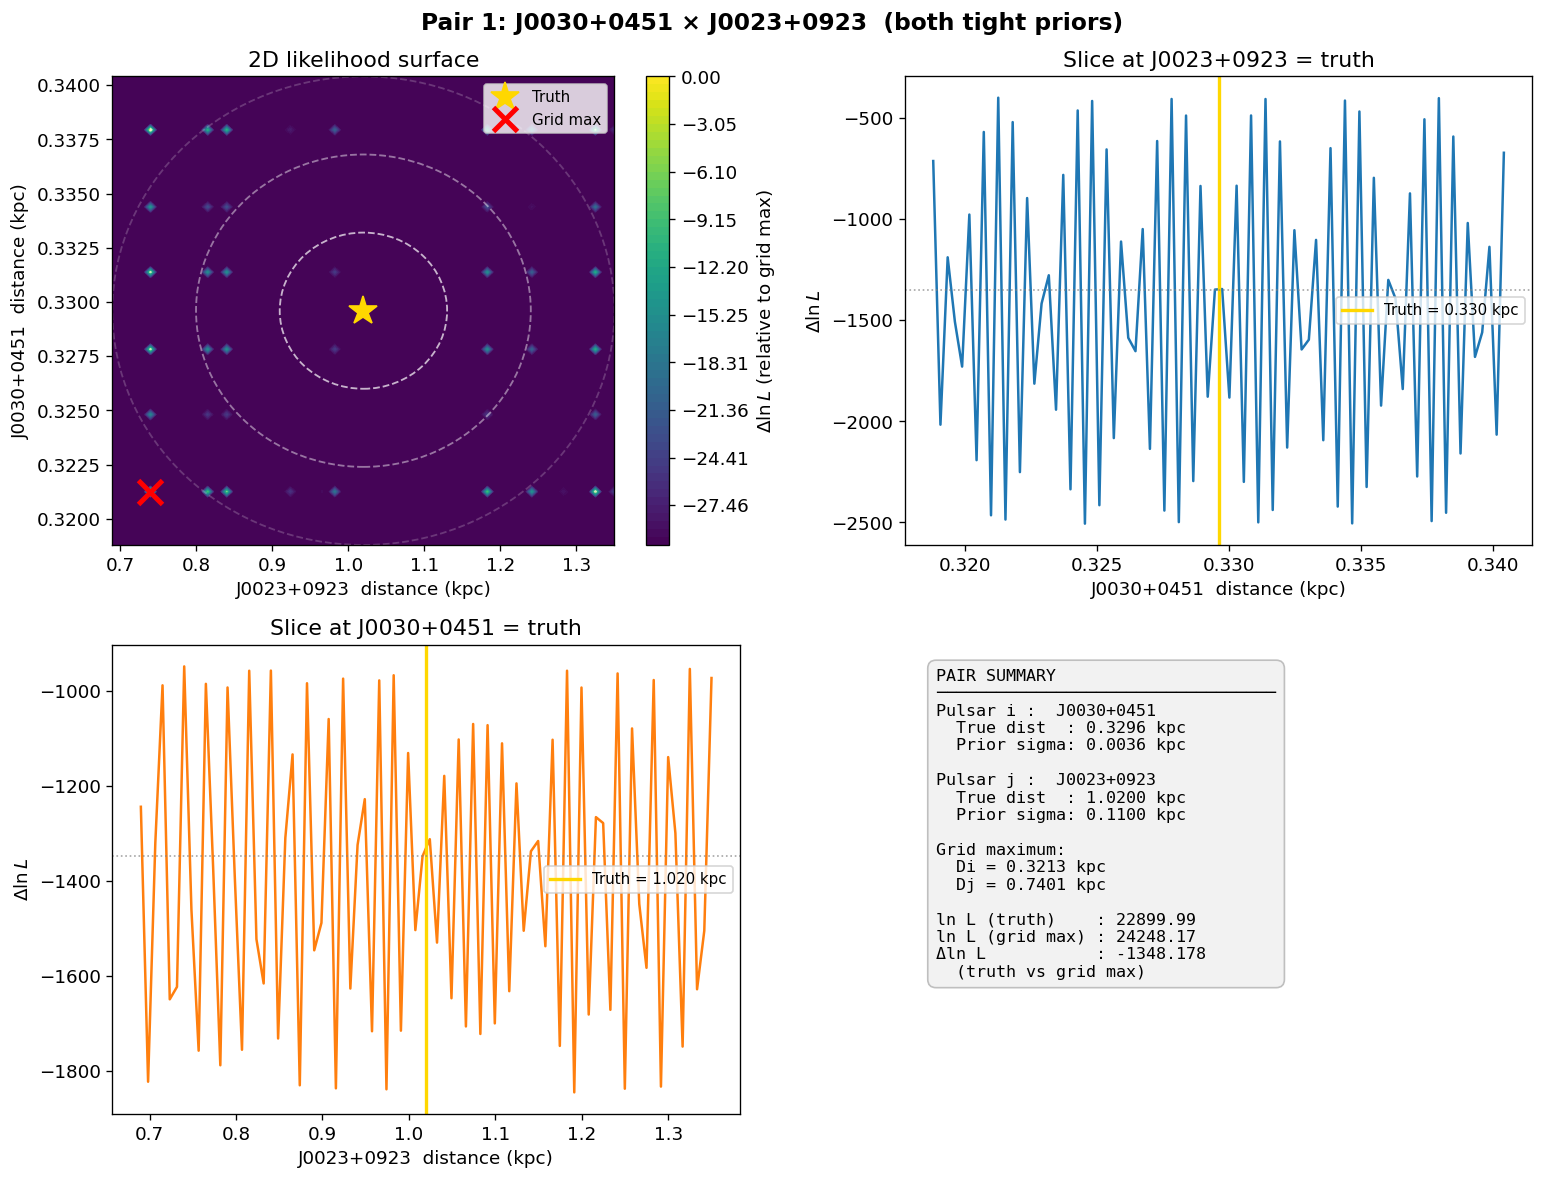

In [30]:
fig_p1 = plot_2d_scan(
    grid_i_p1, grid_j_p1, lnL_p1,
    true_i=pair1_i.pdist[0],
    true_j=pair1_j.pdist[0],
    psr_name_i=pair1_i.name,
    psr_name_j=pair1_j.name,
    prior_sigma_i=pair1_i.pdist[1],
    prior_sigma_j=pair1_j.pdist[1],
    title=f"Pair 1: {pair1_i.name} × {pair1_j.name}  (both tight priors)",
)
plt.show()

## 7. Pair 2 — tight prior + wide prior

Same CW injection and likelihood. One pulsar has a much wider EM distance uncertainty.

Expect the 2D surface to be poorly constrained along the wide-prior axis —
the 1D slice through that pulsar's truth distance should show a broad, nearly-flat landscape
with many unresolved modes.

In [31]:
grid_i_p2 = make_grid(pair2_i)
grid_j_p2 = make_grid(pair2_j)
dist_key_i_p2 = f"{pair2_i.name}_cw_p_dist"
dist_key_j_p2 = f"{pair2_j.name}_cw_p_dist"

print("Pair 2 grid ranges:")
print(f"  {pair2_i.name}: [{grid_i_p2[0]:.4f}, {grid_i_p2[-1]:.4f}] kpc")
print(f"  {pair2_j.name}: [{grid_j_p2[0]:.4f}, {grid_j_p2[-1]:.4f}] kpc")
print(f"  Total evaluations: {N_GRID**2:,}")
print()
print("Running 2D scan (vmapped fn already compiled — should be fast) ...")

Pair 2 grid ranges:
  J0030+0451: [0.3188, 0.3404] kpc
  B1953+29: [1.8500, 7.4300] kpc
  Total evaluations: 6,400

Running 2D scan (vmapped fn already compiled — should be fast) ...


In [32]:
t0 = time.time()

_, _, lnL_p2 = scan_pulsar_pair_2d(
    logl_fn, base_values, param_keys,
    dist_key_i_p2, dist_key_j_p2,
    grid_i_p2, grid_j_p2,
)

elapsed = time.time() - t0
ti = np.argmin(np.abs(grid_i_p2 - pair2_i.pdist[0]))
tj = np.argmin(np.abs(grid_j_p2 - pair2_j.pdist[0]))
delta_truth = lnL_p2[ti, tj] - lnL_p2.max()

print(f"Done in {elapsed:.1f} s  ({elapsed / N_GRID**2 * 1e3:.2f} ms/eval)")
print(f"Δln L (truth vs grid max): {delta_truth:.3f}")

Done in 0.3 s  (0.04 ms/eval)
Δln L (truth vs grid max): -2104.689


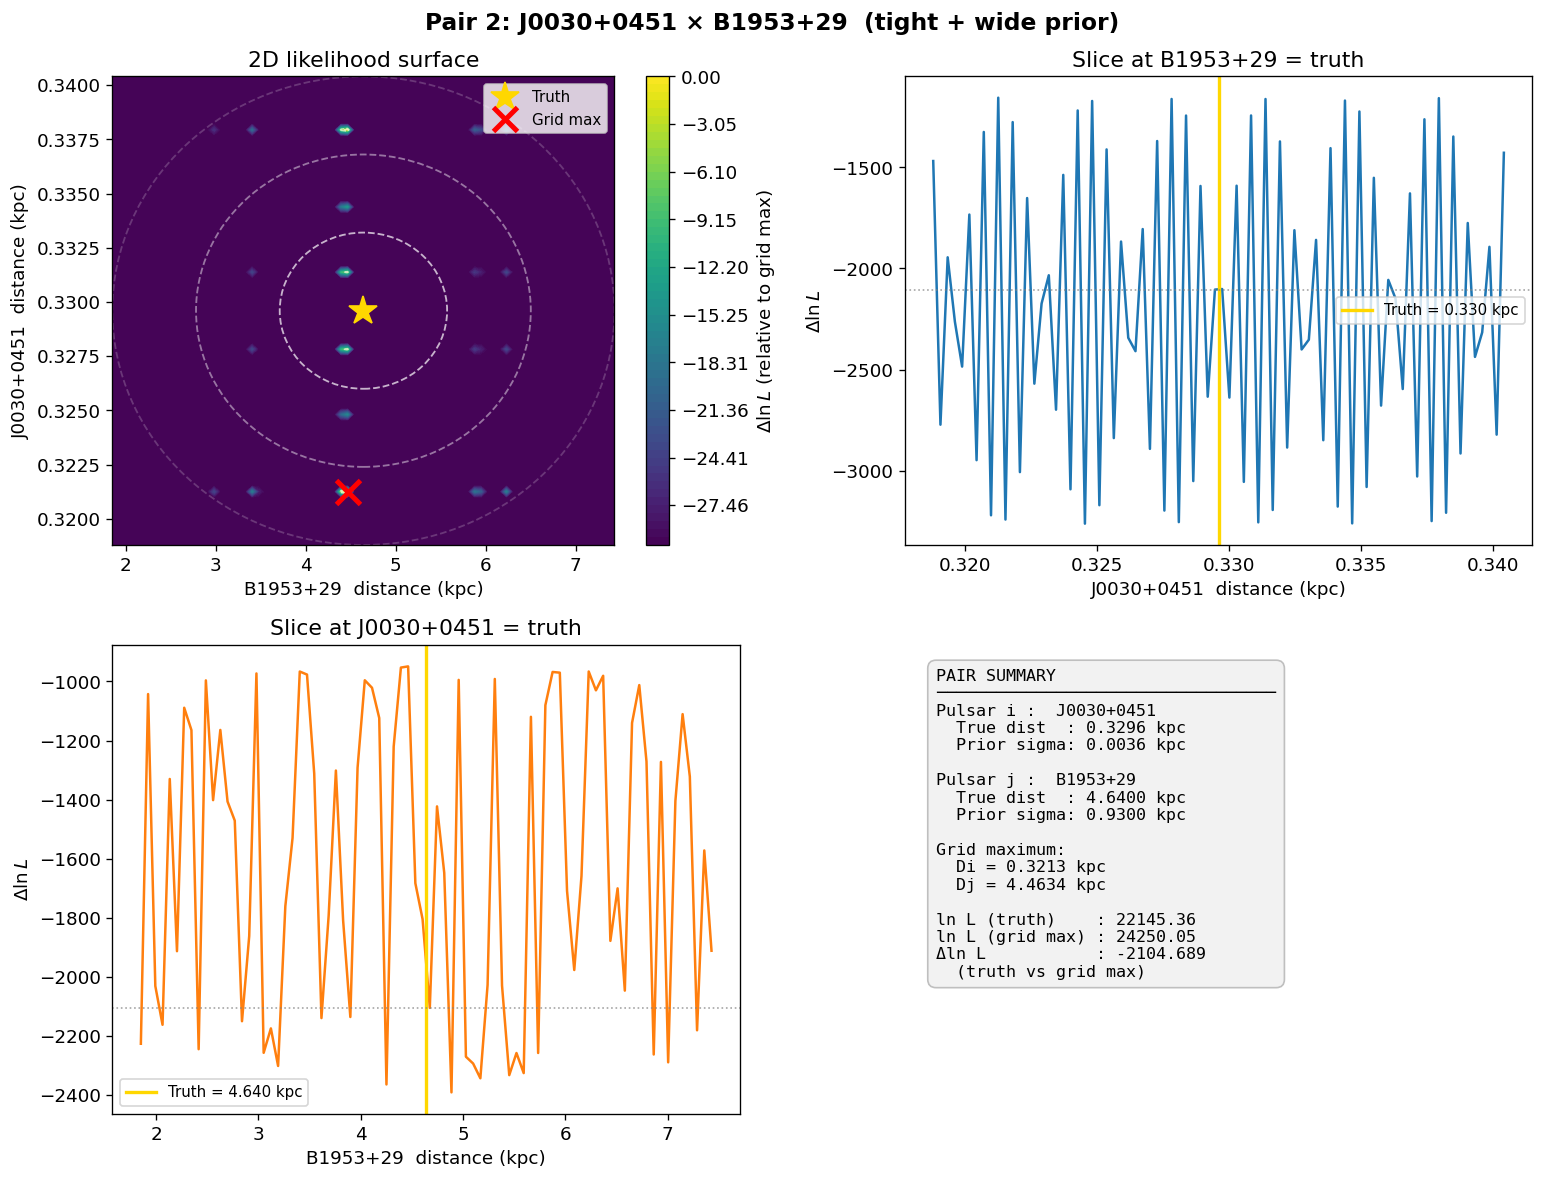

In [33]:
fig_p2 = plot_2d_scan(
    grid_i_p2, grid_j_p2, lnL_p2,
    true_i=pair2_i.pdist[0],
    true_j=pair2_j.pdist[0],
    psr_name_i=pair2_i.name,
    psr_name_j=pair2_j.name,
    prior_sigma_i=pair2_i.pdist[1],
    prior_sigma_j=pair2_j.pdist[1],
    title=f"Pair 2: {pair2_i.name} × {pair2_j.name}  (tight + wide prior)",
)
plt.show()

---
## Validation — 1D per-pulsar likelihood checks

Two quick sanity checks before the 2D scans.

| Mode | Other distances fixed at | Purpose |
|------|--------------------------|---------|
| **Cell A — Cheat** | Injected truth values | Verify likelihood surface is correct: truth should be at or near max |
| **Cell B — Realistic** | EM prior means (pdist[0]) | Starting landscape for coordinate-ascent: mirrors what a sampler sees on step 1 |

In this noise-free setup `truth = pdist[0]`, so A and B are numerically identical.
The two code paths are kept separate so they remain correct when noise is added.

In [ ]:
# Construct base_values_prior: all distances set to EM prior mean (pdist[0]).
# In this noise-free injection, truth = pdist[0], so these are numerically equal.
# The two vectors are built separately so the code is correct in the general case
# (e.g. when noise shifts the recovered peak away from the EM mean).

base_values_prior = np.array(base_values, copy=True)
for psr in disco_psrs:
    dk = f"{psr.name}_cw_p_dist"
    if dk in param_keys:
        base_values_prior[param_keys.index(dk)] = psr.pdist[0]
base_values_prior = jnp.array(base_values_prior)

print("Distance parameters — truth vs prior mean:")
print(f"  {'Pulsar':18s}  {'truth (kpc)':>12}  {'prior mean (kpc)':>18}  {'diff':>12}")
print("─" * 68)
for psr in disco_psrs:
    dk = f"{psr.name}_cw_p_dist"
    if dk in param_keys:
        idx = param_keys.index(dk)
        vt = float(base_values[idx])
        vp = float(base_values_prior[idx])
        print(f"  {psr.name:18s}  {vt:12.4f}  {vp:18.4f}  {vt - vp:+12.6f}")

print()
print(f"ln L(base_values)       = {float(logl_fn(base_values)):.4f}")
print(f"ln L(base_values_prior) = {float(logl_fn(base_values_prior)):.4f}")

### Cell A — Cheat mode: all other distances at truth

Expected: truth near grid max (Δln L ≈ 0). Flag if Δln L < −10 (would indicate a bug in the likelihood or injection).

In [ ]:
print("Cell A — Cheat mode: 1D scans, all other distances fixed at TRUTH")
print("=" * 72)
hdr = (f"{'Pulsar':18s}  {'true d':>10}  {'grid max d':>12}  "
       f"{'ΔlnL':>8}  Status")
print(hdr)
print("─" * len(hdr))

cell_a_results = {}
for psr in disco_psrs:
    dk = f"{psr.name}_cw_p_dist"
    if dk not in param_keys:
        continue
    mu, sig = psr.pdist
    scan_d, scan_ll = scan_pulsar_distance(
        logl_fn, base_values, param_keys, dk,
        max(0.01, mu - 3.0 * sig), mu + 3.0 * sig,
        n_points=2000, required_points=[mu],
    )
    true_ll = float(np.interp(mu, scan_d, scan_ll))
    max_idx  = int(np.argmax(scan_ll))
    max_d    = float(scan_d[max_idx])
    delta    = true_ll - float(scan_ll[max_idx])
    flag     = "" if delta >= -10 else "  ← SUSPICIOUS (ΔlnL < −10)"
    print(f"{psr.name:18s}  {mu:10.4f}  {max_d:12.4f}  {delta:8.3f}{flag}")
    cell_a_results[psr.name] = dict(scan_d=scan_d, scan_ll=scan_ll,
                                     true_d=mu, max_d=max_d, delta=delta)


### Cell B — Realistic mode: all other distances at prior means

Shows the 1D landscape a coordinate-ascent algorithm would see on its first step, before any distances have been optimised.

In [ ]:
print("Cell B — Realistic mode: 1D scans, all other distances fixed at PRIOR MEANS")
print("=" * 76)
hdr = (f"{'Pulsar':18s}  {'true d':>10}  {'grid max d':>12}  "
       f"{'ΔlnL':>8}  Status")
print(hdr)
print("─" * len(hdr))

cell_b_results = {}
for psr in disco_psrs:
    dk = f"{psr.name}_cw_p_dist"
    if dk not in param_keys:
        continue
    mu, sig = psr.pdist
    scan_d, scan_ll = scan_pulsar_distance(
        logl_fn, base_values_prior, param_keys, dk,
        max(0.01, mu - 3.0 * sig), mu + 3.0 * sig,
        n_points=2000, required_points=[mu],
    )
    true_ll = float(np.interp(mu, scan_d, scan_ll))
    max_idx  = int(np.argmax(scan_ll))
    max_d    = float(scan_d[max_idx])
    delta    = true_ll - float(scan_ll[max_idx])
    flag     = "" if delta >= -10 else "  ← SUSPICIOUS (ΔlnL < −10)"
    print(f"{psr.name:18s}  {mu:10.4f}  {max_d:12.4f}  {delta:8.3f}{flag}")
    cell_b_results[psr.name] = dict(scan_d=scan_d, scan_ll=scan_ll,
                                     true_d=mu, max_d=max_d, delta=delta)

print()
print("Cell A vs Cell B Δ comparison:")
print(f"  {'Pulsar':18s}  {'ΔlnL (A)':>10}  {'ΔlnL (B)':>10}  {'A − B':>10}")
print("─" * 56)
for psr in disco_psrs:
    if psr.name in cell_a_results and psr.name in cell_b_results:
        da = cell_a_results[psr.name]["delta"]
        db = cell_b_results[psr.name]["delta"]
        print(f"  {psr.name:18s}  {da:10.3f}  {db:10.3f}  {da - db:+10.6f}")
print()
print("Note: in this noise-free setup truth = pdist[0], so A and B should agree exactly.")


---
## Enhanced pair scans: adaptive grid + two-stage zoom

For each pair, two 4-panel figures are produced:

| Figure | `base_values` used | Other distances | Purpose |
|--------|-------------------|-----------------|---------|
| **Fig 1** | `base_values` | truth | Verify 2D surface (ground truth check) |
| **Fig 2** | `base_values_prior` | prior means | Realistic starting landscape |

**Grid strategy**
- *Stage 1 — coarse*: fixed 40×40 over ±3σ to locate the dominant peak.
- *Stage 2 — fine*: adaptive resolution (4 pts / mode spacing, ≥ 60 pts) zoomed ±4 × dL around the coarse peak.

`adaptive_n_points` ensures roughly 4 evaluations resolve each mode within the zoom window.

In [ ]:
def two_stage_scan_2d(
    logl_fn, base_values, param_keys,
    psr_i, psr_j, cw_p,
    dist_key_i=None, dist_key_j=None,
    n_sigma=3.0, pts_per_mode=8, zoom_modes=3, n_coarse=None,
):
    """Resolved local 2D scan around current distances.

    The old notebook version first did a very coarse full-prior scan. That aliases
    badly when the prior contains hundreds/thousands of CW distance modes, so it
    can zoom around a wrong mode and exclude truth. For diagnostics here, current
    distances are the truth/prior means, so use a local ±zoom_modes*dL window and
    force truth onto the grid.
    """
    print(
        f"  Local window: ±{zoom_modes}×dL around current values "
        f"({pts_per_mode} pts/mode, truth forced onto grid) ..."
    )
    res = scan_pair_window_2d(
        logl_fn, base_values, param_keys,
        psr_i, psr_j, [cw_p],
        center_i=float(base_values[param_keys.index(f"{psr_i.name}_cw_p_dist")]),
        center_j=float(base_values[param_keys.index(f"{psr_j.name}_cw_p_dist")]),
        half_width_modes=zoom_modes,
        points_per_mode=pts_per_mode,
        include_truth=True,
    )
    gi, gj, lnL = res["grid_i"], res["grid_j"], res["lnL"]
    print(
        f"    peak at ({res['peak_i']:.4f}, {res['peak_j']:.4f}) kpc   "
        f"lnL = {res['peak_lnL']:.2f}"
    )
    return {
        "coarse": (gi, gj, lnL),
        "fine": (gi, gj, lnL),
        "peak_coarse": (res["peak_i"], res["peak_j"]),
        "dL_i": res["dL_i"], "dL_j": res["dL_j"],
        "n_i": len(gi), "n_j": len(gj),
    }


### Pair 1 — two tightest priors: Figure 1 (others at truth) + Figure 2 (others at prior means)

In [ ]:
dk1_i = f"{pair1_i.name}_cw_p_dist"
dk1_j = f"{pair1_j.name}_cw_p_dist"

print(f"Pair 1 — Figure 1: others fixed at TRUTH")
print(f"  {pair1_i.name}  ×  {pair1_j.name}")
t0 = time.time()

res_p1_1 = two_stage_scan_2d(
    logl_fn, base_values, param_keys,
    pair1_i, pair1_j, CW_PARAMS[0],
    dk1_i, dk1_j,
)

elapsed = time.time() - t0
gi, gj, lnL = res_p1_1["fine"]
truth_i, truth_j = pair1_i.pdist[0], pair1_j.pdist[0]
in_view = (gi[0] <= truth_i <= gi[-1]) and (gj[0] <= truth_j <= gj[-1])
peak_i, peak_j = res_p1_1["peak_coarse"]

print(f"  Total: {elapsed:.1f} s")
print(f"  Fine grid: {len(gi)}×{len(gj)} = {len(gi)*len(gj):,} evals")
print(f"  Truth ({pair1_i.pdist[0]:.4f}, {pair1_j.pdist[0]:.4f}) kpc "
      f"{'IN' if in_view else 'OUTSIDE'} fine-zoom window")
print()

fig_p1_1 = plot_2d_scan(
    gi, gj, lnL,
    true_i=truth_i, true_j=truth_j,
    psr_name_i=pair1_i.name, psr_name_j=pair1_j.name,
    prior_sigma_i=pair1_i.pdist[1], prior_sigma_j=pair1_j.pdist[1],
    title=(f"Pair 1 | others at truth | "
           f"{pair1_i.name} × {pair1_j.name} (fine zoom)"),
)
plt.show()

In [ ]:
dk1_i = f"{pair1_i.name}_cw_p_dist"
dk1_j = f"{pair1_j.name}_cw_p_dist"

print(f"Pair 1 — Figure 2: others fixed at PRIOR MEANS")
print(f"  {pair1_i.name}  ×  {pair1_j.name}")
t0 = time.time()

res_p1_2 = two_stage_scan_2d(
    logl_fn, base_values_prior, param_keys,
    pair1_i, pair1_j, CW_PARAMS[0],
    dk1_i, dk1_j,
)

elapsed = time.time() - t0
gi, gj, lnL = res_p1_2["fine"]
truth_i, truth_j = pair1_i.pdist[0], pair1_j.pdist[0]
in_view = (gi[0] <= truth_i <= gi[-1]) and (gj[0] <= truth_j <= gj[-1])
peak_i, peak_j = res_p1_2["peak_coarse"]

print(f"  Total: {elapsed:.1f} s")
print(f"  Fine grid: {len(gi)}×{len(gj)} = {len(gi)*len(gj):,} evals")
print(f"  Truth ({pair1_i.pdist[0]:.4f}, {pair1_j.pdist[0]:.4f}) kpc "
      f"{'IN' if in_view else 'OUTSIDE'} fine-zoom window")
print()

fig_p1_2 = plot_2d_scan(
    gi, gj, lnL,
    true_i=truth_i, true_j=truth_j,
    psr_name_i=pair1_i.name, psr_name_j=pair1_j.name,
    prior_sigma_i=pair1_i.pdist[1], prior_sigma_j=pair1_j.pdist[1],
    title=(f"Pair 1 | others at prior means | "
           f"{pair1_i.name} × {pair1_j.name} (fine zoom)"),
)
plt.show()

### Pair 2 — tight + wide prior: Figure 1 (others at truth) + Figure 2 (others at prior means)

In [ ]:
dk2_i = f"{pair2_i.name}_cw_p_dist"
dk2_j = f"{pair2_j.name}_cw_p_dist"

print(f"Pair 2 — Figure 1: others fixed at TRUTH")
print(f"  {pair2_i.name}  ×  {pair2_j.name}")
t0 = time.time()

res_p2_1 = two_stage_scan_2d(
    logl_fn, base_values, param_keys,
    pair2_i, pair2_j, CW_PARAMS[0],
    dk2_i, dk2_j,
)

elapsed = time.time() - t0
gi, gj, lnL = res_p2_1["fine"]
truth_i, truth_j = pair2_i.pdist[0], pair2_j.pdist[0]
in_view = (gi[0] <= truth_i <= gi[-1]) and (gj[0] <= truth_j <= gj[-1])
peak_i, peak_j = res_p2_1["peak_coarse"]

print(f"  Total: {elapsed:.1f} s")
print(f"  Fine grid: {len(gi)}×{len(gj)} = {len(gi)*len(gj):,} evals")
print(f"  Truth ({pair2_i.pdist[0]:.4f}, {pair2_j.pdist[0]:.4f}) kpc "
      f"{'IN' if in_view else 'OUTSIDE'} fine-zoom window")
print()

fig_p2_1 = plot_2d_scan(
    gi, gj, lnL,
    true_i=truth_i, true_j=truth_j,
    psr_name_i=pair2_i.name, psr_name_j=pair2_j.name,
    prior_sigma_i=pair2_i.pdist[1], prior_sigma_j=pair2_j.pdist[1],
    title=(f"Pair 2 | others at truth | "
           f"{pair2_i.name} × {pair2_j.name} (fine zoom)"),
)
plt.show()

In [ ]:
dk2_i = f"{pair2_i.name}_cw_p_dist"
dk2_j = f"{pair2_j.name}_cw_p_dist"

print(f"Pair 2 — Figure 2: others fixed at PRIOR MEANS")
print(f"  {pair2_i.name}  ×  {pair2_j.name}")
t0 = time.time()

res_p2_2 = two_stage_scan_2d(
    logl_fn, base_values_prior, param_keys,
    pair2_i, pair2_j, CW_PARAMS[0],
    dk2_i, dk2_j,
)

elapsed = time.time() - t0
gi, gj, lnL = res_p2_2["fine"]
truth_i, truth_j = pair2_i.pdist[0], pair2_j.pdist[0]
in_view = (gi[0] <= truth_i <= gi[-1]) and (gj[0] <= truth_j <= gj[-1])
peak_i, peak_j = res_p2_2["peak_coarse"]

print(f"  Total: {elapsed:.1f} s")
print(f"  Fine grid: {len(gi)}×{len(gj)} = {len(gi)*len(gj):,} evals")
print(f"  Truth ({pair2_i.pdist[0]:.4f}, {pair2_j.pdist[0]:.4f}) kpc "
      f"{'IN' if in_view else 'OUTSIDE'} fine-zoom window")
print()

fig_p2_2 = plot_2d_scan(
    gi, gj, lnL,
    true_i=truth_i, true_j=truth_j,
    psr_name_i=pair2_i.name, psr_name_j=pair2_j.name,
    prior_sigma_i=pair2_i.pdist[1], prior_sigma_j=pair2_j.pdist[1],
    title=(f"Pair 2 | others at prior means | "
           f"{pair2_i.name} × {pair2_j.name} (fine zoom)"),
)
plt.show()